In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.hvo_model import get_hvo_k, solve_hvo_kinetics, calculate_hvo_conversion
from src.emissions_analysis import emissions_reduction, compare_all_feedstocks, plot_emissions_comparison

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerie importate")

✅ Librerie importate


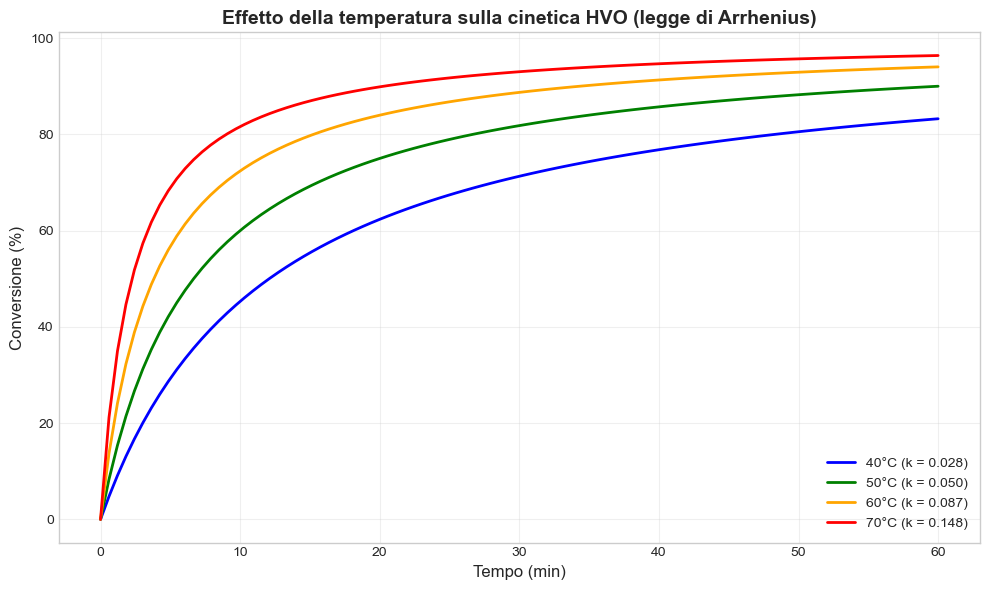

✅ Grafico salvato in output/hvo_arrhenius_effect.png


In [2]:
# Confronto cinetico HVO con Arrhenius a diverse temperature
TG0 = 1.0
H20 = 3.0
initial_C = [TG0, H20, 0, 0]
t = np.linspace(0, 60, 100)

temperatures = [313.15, 323.15, 333.15, 343.15]  # 40°C, 50°C, 60°C, 70°C
temp_labels = ['40°C', '50°C', '60°C', '70°C']
colors = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for T, label, color in zip(temperatures, temp_labels, colors):
    k_hvo = get_hvo_k(T, 'virgin_oil')
    solution = solve_hvo_kinetics(initial_C, t, [k_hvo])
    conversion = calculate_hvo_conversion(solution)
    ax.plot(t, conversion, color=color, linewidth=2, label=f'{label} (k = {k_hvo:.3f})')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione (%)', fontsize=12)
ax.set_title('Effetto della temperatura sulla cinetica HVO (legge di Arrhenius)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/hvo_arrhenius_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato in output/hvo_arrhenius_effect.png")

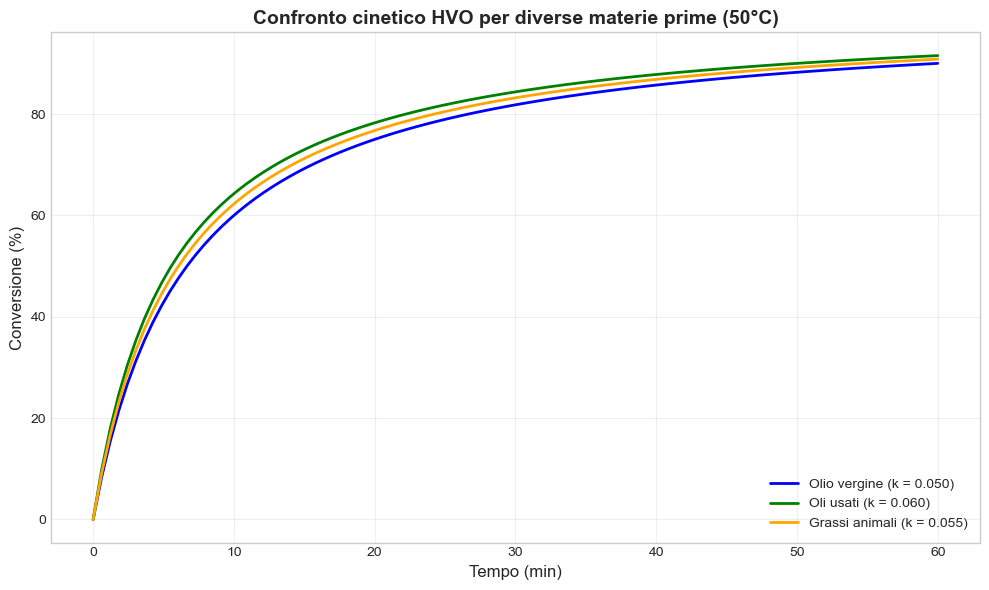

✅ Grafico salvato in output/hvo_feedstock_comparison.png


In [3]:
# Confronto tra diverse materie prime per HVO
feedstocks = ['virgin_oil', 'waste_oil', 'animal_fat']
feedstock_labels = ['Olio vergine', 'Oli usati', 'Grassi animali']
colors = ['blue', 'green', 'orange']

fig, ax = plt.subplots(figsize=(10, 6))

for feedstock, label, color in zip(feedstocks, feedstock_labels, colors):
    k_hvo = get_hvo_k(323.15, feedstock)  # 50°C
    solution = solve_hvo_kinetics(initial_C, t, [k_hvo])
    conversion = calculate_hvo_conversion(solution)
    ax.plot(t, conversion, color=color, linewidth=2, 
            label=f'{label} (k = {k_hvo:.3f})')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione (%)', fontsize=12)
ax.set_title('Confronto cinetico HVO per diverse materie prime (50°C)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/hvo_feedstock_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato in output/hvo_feedstock_comparison.png")

In [4]:
# Analisi emissioni
print("\n" + "="*60)
print("ANALISI EMISSIONI - FAME vs HVO")
print("="*60)

df = compare_all_feedstocks()
print("\n📊 Tabella comparativa emissioni:\n")
print(df.to_string(index=False))

# Calcolo riduzione per HVO con oli usati
emissions, reduction = emissions_reduction('HVO', 'waste_oil')
print(f"\n📈 HVO con oli usati:")
print(f"   Emissioni: {emissions:.1f} g CO₂/MJ")
print(f"   Riduzione vs diesel: {reduction:.1f}%")


ANALISI EMISSIONI - FAME vs HVO

📊 Tabella comparativa emissioni:

Processo  Materia prima  Emissioni (g CO2/MJ)  Riduzione vs diesel (%)
    FAME   Olio vergine                  70.0                     25.5
     HVO   Olio vergine                  60.0                     36.2
    FAME      Oli usati                  50.0                     46.8
     HVO      Oli usati                  40.0                     57.4
    FAME Grassi animali                  55.0                     41.5
     HVO Grassi animali                  45.0                     52.1

📈 HVO con oli usati:
   Emissioni: 40.0 g CO₂/MJ
   Riduzione vs diesel: 57.4%


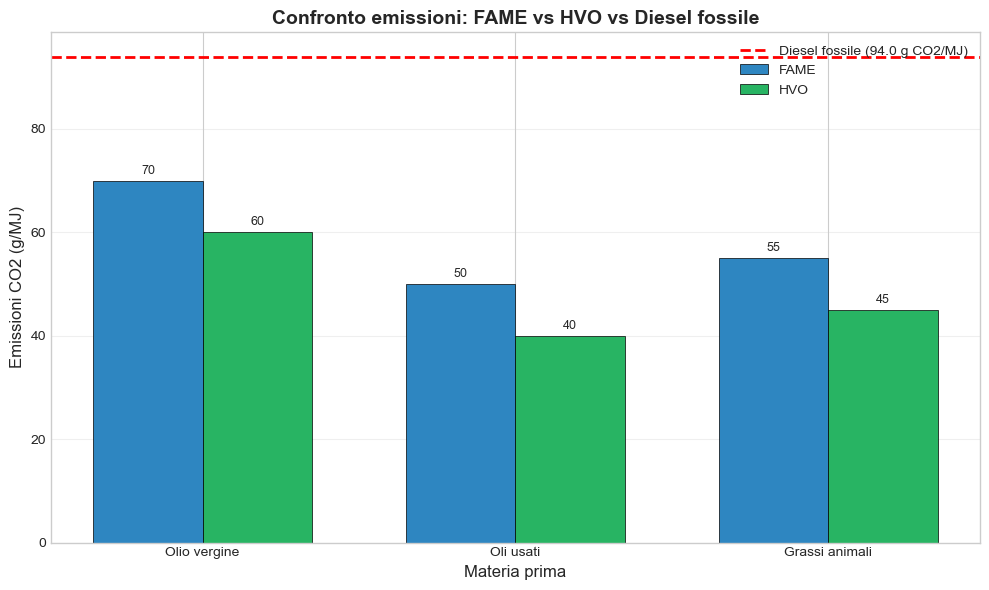

✅ Grafico salvato in output/emissions_comparison.png


In [5]:
# Genera grafico emissioni
plot_emissions_comparison()

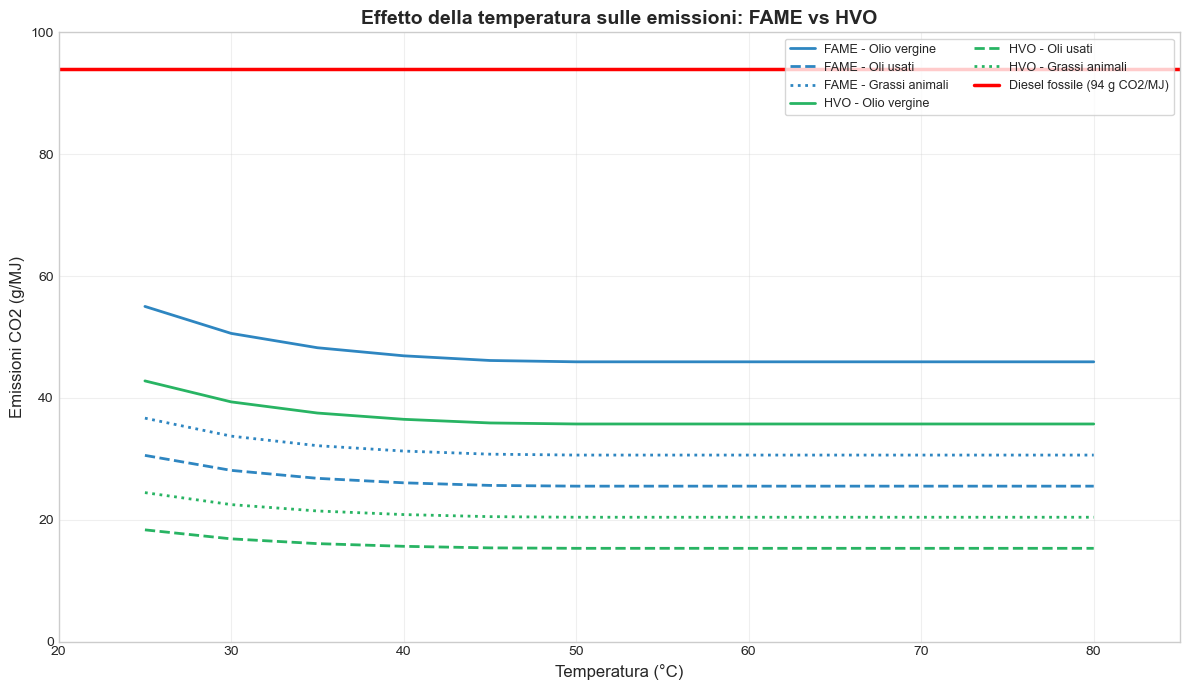

✅ Grafico aggiornato salvato in output/emissions_temperature_effect.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Temperature
temperatures = np.linspace(25, 80, 12)  # °C

# Funzione emissioni in funzione della temperatura
def emissions_vs_T(base_emissions_100, T):
    conversion = 0.7 + 0.3 * (1 - np.exp(-0.1 * (T - 20)))
    conversion = np.clip(conversion, 0.7, 0.98)
    return base_emissions_100 / conversion

# Emissioni base a conversione 100% (g CO₂/MJ)
emissions_base = {
    ('FAME', 'virgin_oil'): 45.0,
    ('FAME', 'waste_oil'): 25.0,
    ('FAME', 'animal_fat'): 30.0,
    ('HVO', 'virgin_oil'): 35.0,
    ('HVO', 'waste_oil'): 15.0,
    ('HVO', 'animal_fat'): 20.0,
}

# Colori e stili
colors = {
    ('FAME', 'virgin_oil'): ('#2E86C1', '-'),
    ('FAME', 'waste_oil'): ('#2E86C1', '--'),
    ('FAME', 'animal_fat'): ('#2E86C1', ':'),
    ('HVO', 'virgin_oil'): ('#28B463', '-'),
    ('HVO', 'waste_oil'): ('#28B463', '--'),
    ('HVO', 'animal_fat'): ('#28B463', ':'),
}

labels = {
    ('FAME', 'virgin_oil'): 'FAME - Olio vergine',
    ('FAME', 'waste_oil'): 'FAME - Oli usati',
    ('FAME', 'animal_fat'): 'FAME - Grassi animali',
    ('HVO', 'virgin_oil'): 'HVO - Olio vergine',
    ('HVO', 'waste_oil'): 'HVO - Oli usati',
    ('HVO', 'animal_fat'): 'HVO - Grassi animali',
}

fig, ax = plt.subplots(figsize=(12, 7))

for (process, feedstock), base_em in emissions_base.items():
    color, linestyle = colors[(process, feedstock)]
    emissions = emissions_vs_T(base_em, temperatures)
    ax.plot(temperatures, emissions, color=color, linestyle=linestyle, 
            linewidth=2, label=labels[(process, feedstock)])

# Diesel fossile (linea di riferimento)
ax.axhline(y=94, color='red', linestyle='-', linewidth=2.5, 
           label='Diesel fossile (94 g CO2/MJ)')

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Emissioni CO2 (g/MJ)', fontsize=12)
ax.set_title('Effetto della temperatura sulle emissioni: FAME vs HVO', 
             fontsize=14, fontweight='bold')
ax.set_xlim(20, 85)
ax.set_ylim(0, 100)

# Legenda con 2 colonne posizionata a destra (evita sovrapposizione)
ax.legend(loc='upper right', fontsize=9, ncol=2, frameon=True, fancybox=True, shadow=False)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/emissions_temperature_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico aggiornato salvato in output/emissions_temperature_effect.png")